Plotando distribuições com médias aproximadas...


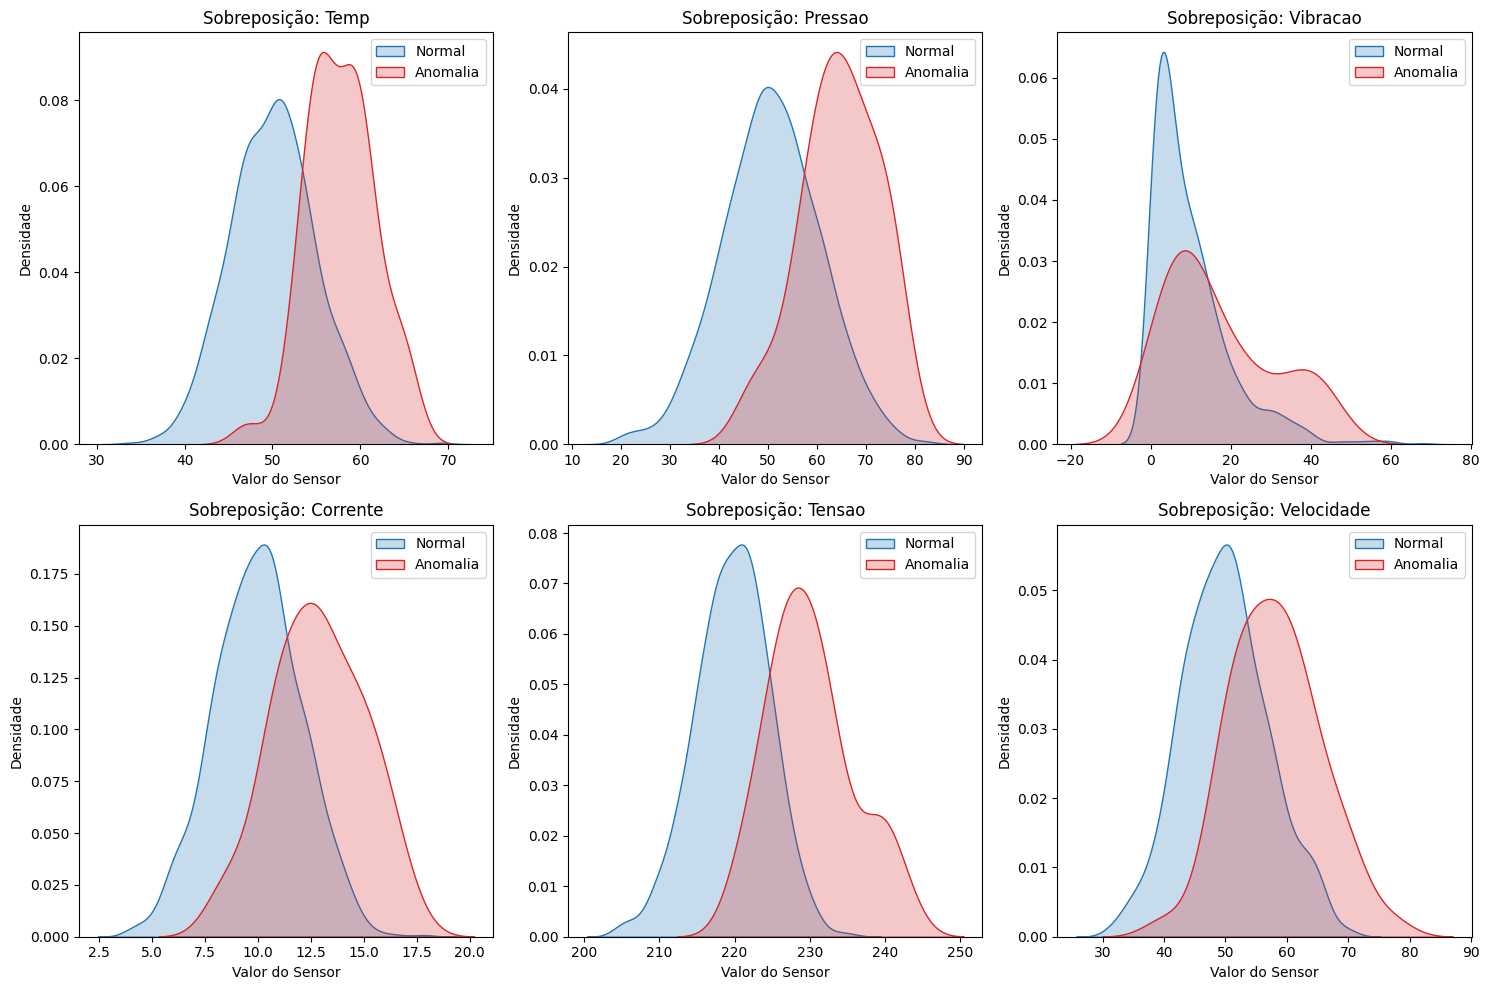


--- Comparativo de Desempenho (Médias Próximas) ---
Nível de Ruído  F1-Score  Precision   Recall
            0%  0.444444   0.500000 0.400000
            5%  0.333333   0.444444 0.266667
           10%  0.347826   0.500000 0.266667


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

def generate_subtle_data(n_normal=1000, n_anom=50):
    np.random.seed(42)
    nomes_sensores = ['Temp', 'Pressao', 'Vibracao', 'Corrente', 'Tensao', 'Velocidade']

    # 1. Dados Normais (Médias padrão)
    X_normal = np.column_stack([
        np.random.normal(50, 5, n_normal),       # Temp
        np.random.normal(50, 10, n_normal),      # Pressão (mudei para normal para facilitar sobreposição)
        np.random.exponential(10, n_normal),     # Vibração
        np.random.normal(10, 2, n_normal),       # Corrente (ajustado)
        np.random.normal(220, 5, n_normal),      # Tensão (ajustado)
        np.random.poisson(50, n_normal)          # Velocidade
    ])

    # 2. Anomalias "Sutis" (Médias próximas aos dados normais)
    # Note que os valores são apenas ligeiramente superiores aos normais
    X_anom = np.column_stack([
        np.random.normal(58, 4, n_anom),         # Temp (58 vs 50)
        np.random.normal(65, 8, n_anom),         # Pressão (65 vs 50)
        np.random.exponential(18, n_anom),       # Vibração (18 vs 10)
        np.random.normal(13, 2, n_anom),         # Corrente (13 vs 10)
        np.random.normal(230, 5, n_anom),        # Tensão (230 vs 220)
        np.random.poisson(60, n_anom)            # Velocidade (60 vs 50)
    ])

    X = np.vstack((X_normal, X_anom))
    y = np.concatenate([np.zeros(n_normal), np.ones(n_anom)])
    return pd.DataFrame(X, columns=nomes_sensores), y

def plot_overlapping_distributions(df, y):
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(df.columns):
        plt.subplot(2, 3, i+1)
        # O KDE mostrará a área de interseção (overlap)
        sns.kdeplot(df[y==0][col], label='Normal', fill=True, color='#1f77b4')
        sns.kdeplot(df[y==1][col], label='Anomalia', fill=True, color='#d62728')
        plt.title(f'Sobreposição: {col}')
        plt.xlabel('Valor do Sensor')
        plt.ylabel('Densidade')
        plt.legend()
    plt.tight_layout()
    plt.show()

def apply_noise(df, level):
    if level == 0: return df.values
    # Ruído calculado sobre o desvio padrão de cada coluna
    # Multiplicador 2.5 para garantir que 10% de ruído crie confusão real
    noise = np.random.normal(0, df.std() * level * 2.5, df.shape)
    return df.values + noise

# --- Fluxo de Execução ---
df_sensores, y = generate_subtle_data()

# Visualização da proximidade das médias
print("Plotando distribuições com médias aproximadas...")
plot_overlapping_distributions(df_sensores, y)



results = []
for level in [0.0, 0.05, 0.10]:
    X_noisy = apply_noise(df_sensores, level)
    X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.3, random_state=42)

    # Contaminação baseada na proporção real de anomalias
    model = IsolationForest(contamination=len(y[y==1])/len(y), random_state=42)
    model.fit(X_train)

    y_pred = np.where(model.predict(X_test) == -1, 1, 0)

    results.append({
        "Nível de Ruído": f"{int(level*100)}%",
        "F1-Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

print("\n--- Comparativo de Desempenho (Médias Próximas) ---")
print(pd.DataFrame(results).to_string(index=False))